In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 91.8 MB/s eta 0:00:00


In [2]:
import os 
print(os.listdir("/kaggle/working"))

['__notebook__.ipynb']


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for f in files:
        print("   ", f)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/biswanath1
/kaggle/input/datasets/biswanath1/dataset1
    Val.csv
    4qb_sel.ipynb
    evaluation_schemes.py
    Train.csv
    Test.csv


In [4]:
import sys

sys.path.append("/kaggle/input/datasets/biswanath1/dataset1")

import evaluation_schemes

print("Success!")

Success!


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, hamming_loss
)
from sklearn.utils.class_weight import compute_class_weight

from tqdm import tqdm
import pennylane as qml
import sys
sys.path.append("/kaggle/input/datasets/biswanath1/dataset1")

from evaluation_schemes import evaluate_all_schemes

In [6]:
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

print("GPU device:", gpu_device)
print("CPU device:", cpu_device)

GPU device: cuda
CPU device: cpu


In [7]:
def set_seed(seed_value=42):
    """Set seeds for reproducibility across PyTorch, NumPy, and Python."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [8]:
df_tr = pd.read_csv("/kaggle/input/datasets/biswanath1/dataset1/Train.csv")
df_vl = pd.read_csv("/kaggle/input/datasets/biswanath1/dataset1/Val.csv")
df_te = pd.read_csv("/kaggle/input/datasets/biswanath1/dataset1/Test.csv")
# Reset indices for safe iloc access in Dataset
df_tr = df_tr.reset_index(drop=True)
df_vl = df_vl.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)

print("Train:", df_tr.shape, "| Valid:", df_vl.shape, "| Test:", df_te.shape)
df_tr.head()

Train: (18420, 11) | Valid: (2047, 11) | Test: (2272, 11)


,ID,Data,Love,Joy,Surprise,Anger,Sadness,Fear,Topic,Domain,is_admin
0,5454,লকাল বাস ভালো এটা থেকে,0,0,0,0,1,0,Travel,Youtube,False
1,22549,কত অভিজানই তো চলে কিন্তু ওয়াসার পানির অভিজান ক...,0,0,0,0,1,0,Politics,Youtube,False
2,7033,বিয়ের মহল ছেড়ে তিনি বিস্রাম নিতে চলে যান (৬ ...,0,0,0,1,0,0,Personal,Facebook,False
3,21114,চাচাজি তো কেবল মাকে ধর্ষণ করেছেন,0,0,0,0,1,0,Education,Facebook,False
4,23683,সত্যিকার মানুষ তারাই ভাই,0,1,0,0,0,0,Personal,Youtube,False


In [9]:
EMOTION_COLS = ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']
TEXT_COL     = 'Data'
NUM_LABELS   = len(EMOTION_COLS)

for split_name, split_df in [('Train', df_tr), ('Valid', df_vl), ('Test', df_te)]:
    assert TEXT_COL in split_df.columns, f"{split_name}: missing column '{TEXT_COL}'"
    assert all(c in split_df.columns for c in EMOTION_COLS), \
        f"{split_name}: missing emotion columns"

print(f"NUM_LABELS = {NUM_LABELS}  →  {EMOTION_COLS}")
print("\nTrain label distribution:")
print(df_tr[EMOTION_COLS].sum().sort_values(ascending=False))

NUM_LABELS = 6  →  ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']

Train label distribution:
Joy         8314
Sadness     4569
Love        3786
Anger       3542
Surprise     848
Fear         279
dtype: int64


In [10]:
class EmoNoBaDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.data      = df
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        encoding = self.tokenizer(
            str(row[TEXT_COL]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        label = torch.tensor(
            row[EMOTION_COLS].values.astype(np.float32),
            dtype=torch.float32
        )

        return (
            encoding['input_ids'].squeeze(0),       # (max_length,)
            encoding['attention_mask'].squeeze(0),  # (max_length,)
            label                                   # (NUM_LABELS,)
        )

In [11]:
TEXT_MODEL   = 'ai4bharat/IndicBERTv2-MLM-only'

tokenizer    = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL).to(gpu_device)

print("Text encoder loaded on:", next(text_encoder.parameters()).device)

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Text encoder loaded on: cuda:0


[tensor(0.26065443, requires_grad=True), tensor(-0.2520586, requires_grad=True), tensor(-0.04135675, requires_grad=True), tensor(0.09198898, requires_grad=True)]


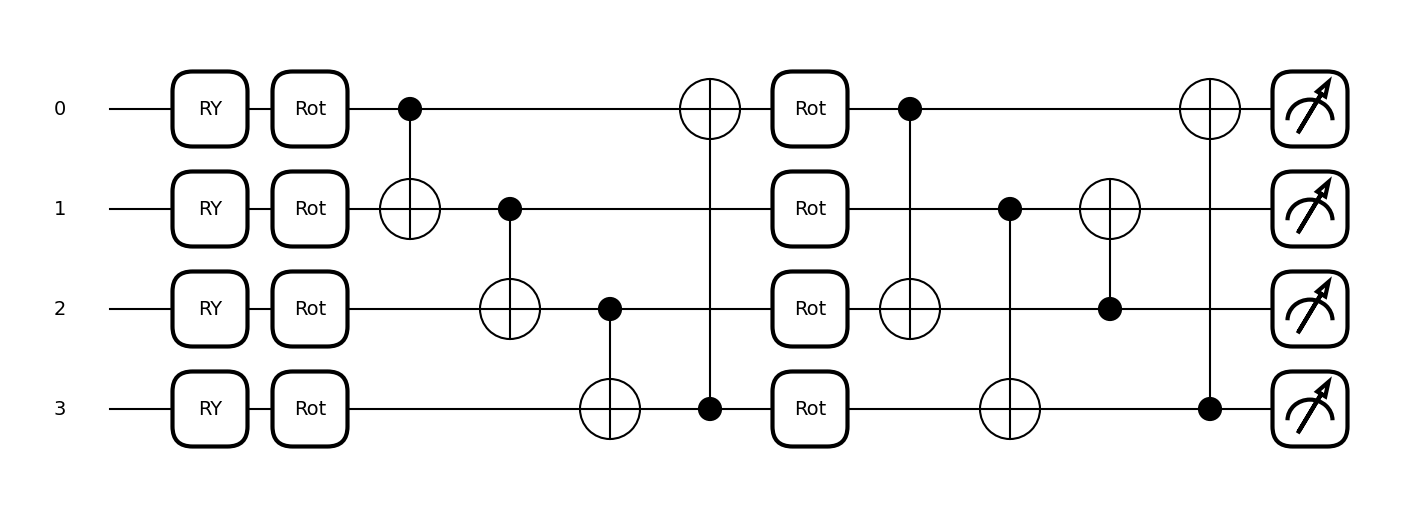

In [1]:
"""

ADD YOUR VQC HERE ...

"""
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

n_qubits = 4
n_qlayers = 1

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def vqc(inputs, weights):

    # Feature Encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Variational Layer
    for i in range(n_qubits):
        qml.Rot(
            weights[0][i][0],
            weights[0][i][1],
            weights[0][i][2],
            wires=i
        )

    # Ring Entanglement
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])
    qml.CNOT(wires=[3,0])

    #2nd Variational Layer
    for i in range(n_qubits):
        qml.Rot(
            weights[0][i][0],
            weights[0][i][1],
            weights[0][i][2],
            wires=i
        )

          # Ring Entanglement
    qml.CNOT(wires=[0,2])
    qml.CNOT(wires=[1,3])
    qml.CNOT(wires=[2,1])
    qml.CNOT(wires=[3,0])



    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

inputs = np.array([0.5,1.0,1.5,2.0])

weights = np.random.random((1,4,3))

print(vqc(inputs, weights))

# Draw the circuit
fig, ax = qml.draw_mpl(vqc)(inputs, weights)
plt.show()

In [13]:
class QuantumBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        # StronglyEntanglingLayers weight shape: (n_layers, n_qubits, 3)
        self.weights = nn.Parameter(
            torch.randn(n_qlayers, n_qubits, 3)   # ← was (N_Q_LAYERS, N_QUBITS)
        )

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = torch.stack(vqc(x[i].cpu(),self.weights.cpu())).to(x.device)
            outputs.append(out)
        return torch.stack(outputs)

In [14]:
class QuantumFusionLayer(nn.Module):
    def __init__(self, in_dim=128, q_dim=4):
        super().__init__()
        assert q_dim == n_qubits, "q_dim must match n_qubits"

        self.pre_q   = nn.Linear(in_dim, q_dim)
        self.quantum = QuantumBottleneck()
        self.post_q  = nn.Linear(q_dim, in_dim)

    def forward(self, x):

        x_q = torch.tanh(self.pre_q(x))
        
        q_out = self.quantum(x_q.to(cpu_device))

        q_out = q_out.to(x.device).float()

        return self.post_q(q_out)                     

In [15]:
class QuantumEmotionClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.text_encoder = text_encoder

        self.text_compressed = nn.Sequential(
            nn.Linear(768, 128),
        )

        self.quantum_fusion = QuantumFusionLayer(in_dim=128, q_dim=n_qubits)

        self.classifier = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask):
        text_feat = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]                       

        text_compressed = self.text_compressed(text_feat)       

        q_out  = self.quantum_fusion(text_compressed)  

        return self.classifier(F.relu(q_out))            

In [16]:
MAX_LEN    = 128
BATCH_SIZE = 8

train_dataset = EmoNoBaDataset(df_tr, tokenizer, MAX_LEN)
val_dataset   = EmoNoBaDataset(df_vl, tokenizer, MAX_LEN)
test_dataset  = EmoNoBaDataset(df_te, tokenizer, MAX_LEN)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=seed_worker, generator=g
)
val_loader   = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 2303 | Val: 256 | Test: 284


In [17]:
label_counts = df_tr[EMOTION_COLS].sum().values
total        = len(df_tr)
pos_weight   = torch.tensor(
    (total - label_counts) / np.clip(label_counts, 1, None),
    dtype=torch.float32
).to(gpu_device)

print("Per-label pos_weight:")
for col, w in zip(EMOTION_COLS, pos_weight.cpu().numpy()):
    print(f"  {col:<12}: {w:.3f}")

Per-label pos_weight:
  Love        : 3.865
  Joy         : 1.216
  Surprise    : 20.722
  Anger       : 4.200
  Sadness     : 3.032
  Fear        : 65.022


In [18]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_gold = [], []

    for input_ids, attn_mask, labels in tqdm(dataloader, desc='Training'):
        input_ids = input_ids.to(gpu_device)
        attn_mask = attn_mask.to(gpu_device)
        labels    = labels.to(gpu_device)       # (B, NUM_LABELS) float32

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)    # (B, NUM_LABELS)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).detach().cpu().numpy().astype(int)
        all_preds.append(preds)
        all_gold.append(labels.detach().cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_gold  = np.vstack(all_gold)
    macro_f1  = f1_score(all_gold, all_preds, average='macro', zero_division=0)

    return total_loss / len(dataloader), macro_f1

In [19]:
def evaluate(model, dataloader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_preds, all_gold = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in dataloader:
            input_ids = input_ids.to(gpu_device)
            attn_mask = attn_mask.to(gpu_device)
            labels    = labels.to(gpu_device)

            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(logits) > threshold).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_gold.append(labels.cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_gold  = np.vstack(all_gold)

    # ── existing metrics ──────────────────────────────────────
    base_metrics = {
        'loss'         : total_loss / len(dataloader),
        'macro_f1'     : f1_score(all_gold, all_preds, average='macro',    zero_division=0),
        'micro_f1'     : f1_score(all_gold, all_preds, average='micro',    zero_division=0),
        'weighted_f1'  : f1_score(all_gold, all_preds, average='weighted', zero_division=0),
        'hamming_loss' : hamming_loss(all_gold, all_preds),
        'preds'        : all_preds,
        'gold'         : all_gold,
    }

    # ── new schemes (Exact Match + Partial Match) ─────────────
    extended = evaluate_all_schemes(
        gold        = all_gold,
        preds       = all_preds,
        label_names = EMOTION_COLS,
        verbose     = False,         # set True to auto-print on every call
    )
    base_metrics['exact_match']   = extended['scheme2']
    base_metrics['partial_match'] = extended['scheme3']

    return base_metrics

In [20]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {
                k: v.detach().cpu() for k, v in model.state_dict().items()
            }
            return False   # do NOT stop
        else:
            self.counter += 1
            return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_state)

In [21]:
model = QuantumEmotionClassifier(num_labels=NUM_LABELS).to(gpu_device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay = 0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6,
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

early_stopping = EarlyStopping(patience=5)

print("Model on:", next(model.parameters()).device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

Model on: cuda:0
Total params: 278,141,718 | Trainable: 278,141,718


In [22]:
NUM_EPOCHS = 25

train_loss_arr = []
val_loss_arr   = []
val_f1_arr     = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
    val_metrics          = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_f1   = val_metrics['macro_f1']

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Macro-F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f} | "
        f"Val Micro-F1: {val_metrics['micro_f1']:.4f} | "
    )

    train_loss_arr.append(train_loss)
    val_loss_arr.append(val_loss)
    val_f1_arr.append(val_f1)

    if early_stopping.step(val_f1, model):
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break


Training: 100%|██████████| 2303/2303 [15:31<00:00,  2.47it/s]


Epoch [01/25] | Train Loss: 1.0898 | Train Macro-F1: 0.3484 | Val Loss: 1.0428 | Val Macro-F1: 0.4423 | Val Micro-F1: 0.5714 | 


Training: 100%|██████████| 2303/2303 [15:20<00:00,  2.50it/s]


Epoch [02/25] | Train Loss: 0.9973 | Train Macro-F1: 0.4223 | Val Loss: 0.9488 | Val Macro-F1: 0.4261 | Val Micro-F1: 0.5495 | 


Training: 100%|██████████| 2303/2303 [15:16<00:00,  2.51it/s]


...

Epoch [23/25] | Train Loss: 0.2979 | Train Macro-F1: 0.8834 | Val Loss: 1.0240 | Val Macro-F1: 0.6183 | Val Micro-F1: 0.7337 | 


Training: 100%|██████████| 2303/2303 [15:05<00:00,  2.54it/s]


Epoch [24/25] | Train Loss: 0.2942 | Train Macro-F1: 0.8854 | Val Loss: 1.0220 | Val Macro-F1: 0.6130 | Val Micro-F1: 0.7334 | 


Training: 100%|██████████| 2303/2303 [14:55<00:00,  2.57it/s]


Epoch [25/25] | Train Loss: 0.2966 | Train Macro-F1: 0.8870 | Val Loss: 1.0207 | Val Macro-F1: 0.6103 | Val Micro-F1: 0.7297 | 
Early stopping triggered at epoch 25.


In [23]:
early_stopping.restore(model)
print(f"Best Val Macro-F1: {early_stopping.best_score:.4f}")

Best Val Macro-F1: 0.6185


In [24]:
test_metrics = evaluate(model, test_loader, criterion)

# Existing metrics
print(f"Test Loss        : {test_metrics['loss']:.4f}")
print(f"Test Macro-F1    : {test_metrics['macro_f1']:.4f}")
print(f"Test Micro-F1    : {test_metrics['micro_f1']:.4f}")
print(f"Test Weighted-F1 : {test_metrics['weighted_f1']:.4f}")
print(f"Test Hamming Loss: {test_metrics['hamming_loss']:.4f}")

# ── Scheme 2 : Exact Match ────────────────────────────────────
em = test_metrics['exact_match']
print(f"\n── Exact Match ──────────────────────────────")
print(f"  Exact Match Ratio : {em['exact_match_ratio']:.4f}")
print(f"  Precision         : {em['precision']:.4f}")
print(f"  Recall            : {em['recall']:.4f}")
print(f"  F1                : {em['f1']:.4f}")

# ── Scheme 3 : Partial Match ──────────────────────────────────
pm = test_metrics['partial_match']
print(f"\n── Partial Match (instance-level) ───────────")
print(f"  Precision         : {pm['precision']:.4f}")
print(f"  Recall            : {pm['recall']:.4f}")
print(f"  F1                : {pm['f1']:.4f}")

# Per-label report (unchanged)
print("\nPer-label Classification Report:")
print(classification_report(
    test_metrics['gold'], test_metrics['preds'],
    target_names=EMOTION_COLS, digits=4, zero_division=0
))

Test Loss        : 2.6140
Test Macro-F1    : 0.4922
Test Micro-F1    : 0.5906
Test Weighted-F1 : 0.5938
Test Hamming Loss: 0.1738

── Exact Match ──────────────────────────────
  Exact Match Ratio : 0.4155
  Precision         : 0.4155
  Recall            : 0.4155
  F1                : 0.4155

── Partial Match (instance-level) ───────────
  Precision         : 0.5996
  Recall            : 0.6845
  F1                : 0.6141

Per-label Classification Report:
              precision    recall  f1-score   support

        Love     0.4762    0.5155    0.4950       388
         Joy     0.6494    0.7465    0.6946       856
    Surprise     0.2259    0.5102    0.3132       147
       Anger     0.5776    0.5639    0.5706       548
     Sadness     0.5748    0.7727    0.6592       607
        Fear     0.2656    0.1889    0.2208        90

   micro avg     0.5424    0.6483    0.5906      2636
   macro avg     0.4616    0.5496    0.4922      2636
weighted avg     0.5551    0.6483    0.5938      26

In [25]:
# os.makedirs('./Preds', exist_ok=True)

# df_out = df_te.copy()
# for i, emotion in enumerate(EMOTION_COLS):
#     df_out[f'{emotion}_pred'] = conf_preds[:, i]

# df_out.to_excel('./Preds/qt_4qb_emoba_indicbertv2.xlsx', index=False)
# print("Predictions saved.")